In [34]:
import pandas as pd
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

In [3]:
df = pd.read_csv('house_price_regression_dataset.csv')

In [4]:
df.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


In [9]:
df.shape

(1000, 8)

In [5]:
df.isnull().sum()

Square_Footage          0
Num_Bedrooms            0
Num_Bathrooms           0
Year_Built              0
Lot_Size                0
Garage_Size             0
Neighborhood_Quality    0
House_Price             0
dtype: int64

In [6]:
df.duplicated().mean()

np.float64(0.0)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Square_Footage        1000 non-null   int64  
 1   Num_Bedrooms          1000 non-null   int64  
 2   Num_Bathrooms         1000 non-null   int64  
 3   Year_Built            1000 non-null   int64  
 4   Lot_Size              1000 non-null   float64
 5   Garage_Size           1000 non-null   int64  
 6   Neighborhood_Quality  1000 non-null   int64  
 7   House_Price           1000 non-null   float64
dtypes: float64(2), int64(6)
memory usage: 62.6 KB


In [8]:
df.describe()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,2815.422000,2.990000,1.973000,1986.550000,2.778087,1.022000,5.615000,6.188610e+05
std,1255.514921,1.427564,0.820332,20.632916,1.297903,0.814973,2.887059,2.535681e+05
min,503.000000,1.000000,1.000000,1950.000000,0.506058,0.000000,1.000000,1.116269e+05
25%,1749.500000,2.000000,1.000000,1969.000000,1.665946,0.000000,3.000000,4.016482e+05
50%,2862.500000,3.000000,2.000000,1986.000000,2.809740,1.000000,6.000000,6.282673e+05
75%,3849.500000,4.000000,3.000000,2004.250000,3.923317,2.000000,8.000000,8.271413e+05
max,4999.000000,5.000000,3.000000,2022.000000,4.989303,2.000000,10.000000,1.108237e+06


In [ ]:
# EDA

                      Square_Footage  Num_Bedrooms  Num_Bathrooms  Year_Built  \
Square_Footage              1.000000     -0.043564      -0.031584   -0.022392   
Num_Bedrooms               -0.043564      1.000000       0.022848   -0.015820   
Num_Bathrooms              -0.031584      0.022848       1.000000   -0.021063   
Year_Built                 -0.022392     -0.015820      -0.021063    1.000000   
Lot_Size                    0.089479     -0.009355       0.034923   -0.061050   
Garage_Size                 0.030593      0.113761       0.024846   -0.025485   
Neighborhood_Quality       -0.008357     -0.049024       0.017585   -0.009549   
House_Price                 0.991261      0.014633      -0.001862    0.051967   

                      Lot_Size  Garage_Size  Neighborhood_Quality  House_Price  
Square_Footage        0.089479     0.030593             -0.008357     0.991261  
Num_Bedrooms         -0.009355     0.113761             -0.049024     0.014633  
Num_Bathrooms         0.034

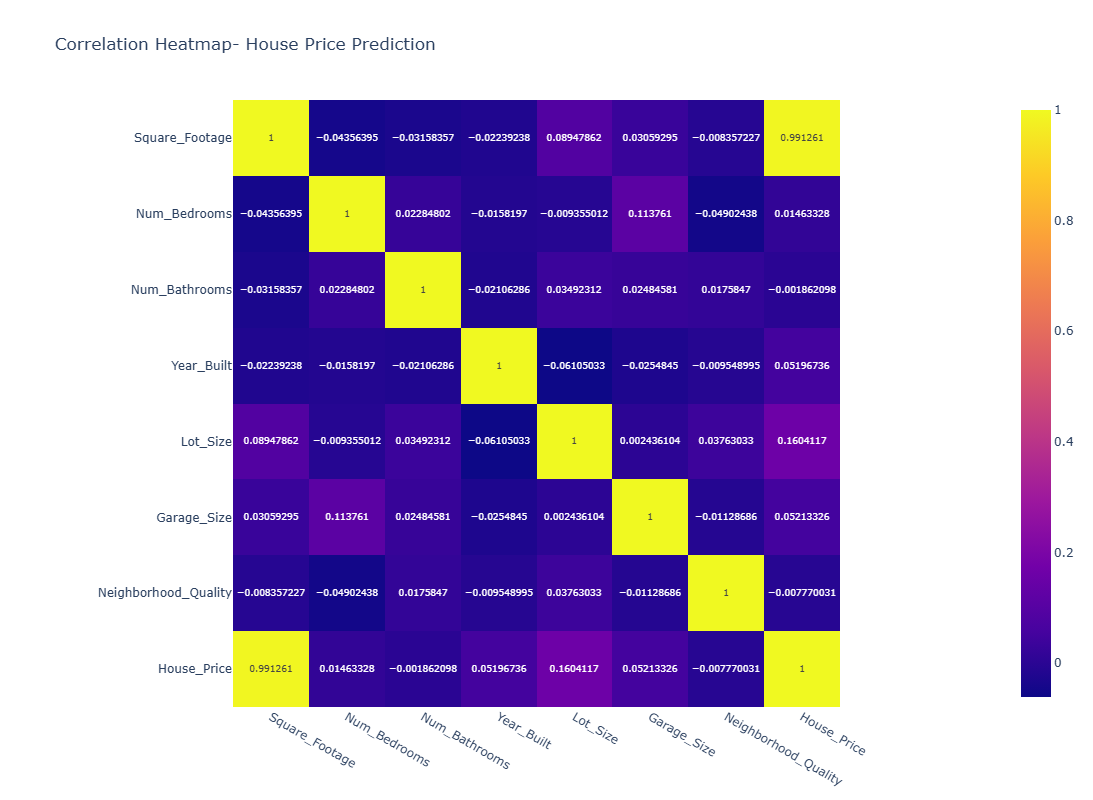

In [15]:
corr = df.corr(numeric_only = True)
print(corr)
fig = px.imshow(corr,text_auto = True, title = "Correlation Heatmap- House Price Prediction")
fig.update_layout(
    width = 900,
    height = 800
)
fig.show()

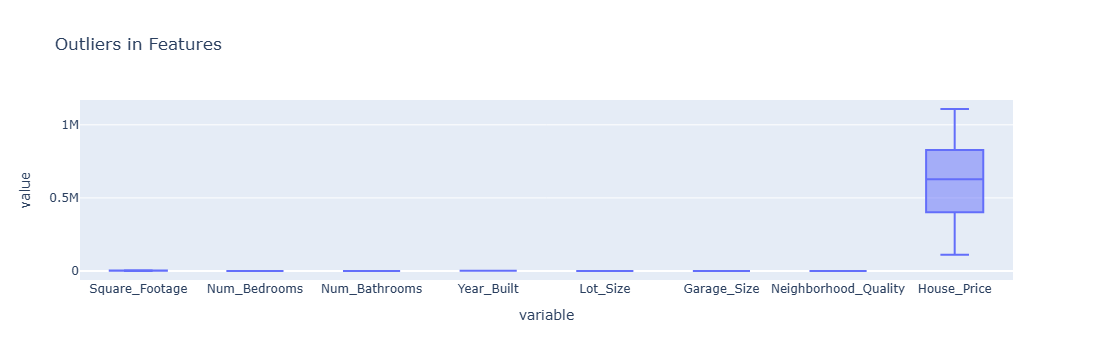

In [18]:
fig = px.box(df.melt(), x = 'variable', y = 'value', title = "Outliers in Features")
fig.show()

In [22]:
X = df.drop("House_Price", axis = 1)
y = df["House_Price"]

In [27]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)

In [28]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(800, 7)
(200, 7)
(800,)
(200,)


In [29]:
model = RandomForestRegressor(max_depth = 6,random_state = 42)

In [30]:
model.fit(X_train,y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,6
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [31]:
y_pred = model.predict(X_test)

In [35]:
r2_score(y_test,y_pred)

0.9906863298140705

In [36]:
print("Train score:", model.score(X_train, y_train))
print("Test score:", model.score(X_test, y_test))

Train score: 0.9953699592733809
Test score: 0.9906863298140705


In [41]:
#After removing square_footage
select = ['House_Price','Square_Footage']
X_new = df.drop(select, axis = 1)
y_new = df['House_Price']

In [42]:
X_new

,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality
0,2,1,1981,0.599637,0,5
1,3,3,2016,4.753014,1,6
2,1,2,2016,3.634823,0,9
3,1,2,1977,2.730667,1,8
4,2,1,1993,4.699073,0,8
...,...,...,...,...,...,...
995,4,1,1978,2.165110,2,10
996,1,2,1999,2.977123,1,10
997,4,2,1962,4.055067,0,2
998,5,2,1950,1.930921,0,7


In [43]:
X_train_n,X_test_n,y_train_n,y_test_n = train_test_split(X_new,y_new,test_size = 0.2,random_state = 42)

In [44]:
print(X_train_n.shape)
print(X_test_n.shape)
print(y_train_n.shape)
print(y_test_n.shape)

(800, 6)
(200, 6)
(800,)
(200,)


In [45]:
model2 = RandomForestRegressor(max_depth = 6,random_state = 42)

In [46]:
model2.fit(X_train_n,y_train_n)

,n_estimators,100
,criterion,'squared_error'
,max_depth,6
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [48]:
y_pred2 = model2.predict(X_test_n)

In [49]:
r2_score(y_test_n,y_pred2)

-0.033842764728838626